In [1]:
import catboost
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
from catboost import CatBoostClassifier, Pool
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split


In [26]:
master_df = pd.read_csv('../data/csv/master_df.csv')
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220688 entries, 0 to 220687
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        220688 non-null  str    
 1   href                      220688 non-null  str    
 2   price                     220688 non-null  int64  
 3   title                     220688 non-null  str    
 4   status                    220688 non-null  str    
 5   content                   220688 non-null  str    
 6   createdAt                 220688 non-null  str    
 7   boostedAt                 220688 non-null  str    
 8   user_dbId                 220688 non-null  int64  
 9   user_nickname             220688 non-null  str    
 10  region_name_from_article  220688 non-null  str    
 11  region_id                 220688 non-null  int64  
 12  region_name               220688 non-null  str    
 13  region_in                 220688 non-null  str    
 14 

In [ ]:
cols = [
    'id',
    'price',
    'title',
    'status',
    'content',
    'createdAt',
    'boostedAt',
    'region_name',
    'crawledAt',
    'favoriteCount',
    'chatCount',
    'viewCount',
    'sellerTemperature',
    'imageCount',
    'brandName',
    'label',
    'coarse_label',
    'days_since_created',
    'created_hour',
    'created_dayofweek',
    'is_boosted',
    'title_len',
    'content_len',
    'days_elapsed',
]

In [28]:
### feature engineering ###
df = master_df[cols]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220688 entries, 0 to 220687
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  220688 non-null  str    
 1   price               220688 non-null  int64  
 2   title               220688 non-null  str    
 3   status              220688 non-null  str    
 4   content             220688 non-null  str    
 5   createdAt           220688 non-null  str    
 6   boostedAt           220688 non-null  str    
 7   region_name         220688 non-null  str    
 8   crawledAt           220688 non-null  str    
 9   favoriteCount       220688 non-null  int64  
 10  chatCount           220688 non-null  int64  
 11  viewCount           220688 non-null  int64  
 12  sellerTemperature   220688 non-null  float64
 13  imageCount          220688 non-null  int64  
 14  brandName           220688 non-null  str    
 15  label               220688 non-null  str    


In [29]:
df.to_csv('../data/csv/parse_brands.csv')

In [30]:
df = pd.read_csv('../data/csv/parse_brands_enriched.csv', index_col=0)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220688 entries, 0 to 220687
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  220688 non-null  str    
 1   price               220688 non-null  int64  
 2   title               220688 non-null  str    
 3   status              220688 non-null  str    
 4   content             220688 non-null  str    
 5   createdAt           220688 non-null  str    
 6   boostedAt           220688 non-null  str    
 7   region_name         220688 non-null  str    
 8   crawledAt           220688 non-null  str    
 9   favoriteCount       220688 non-null  int64  
 10  chatCount           220688 non-null  int64  
 11  viewCount           220688 non-null  int64  
 12  sellerTemperature   220688 non-null  float64
 13  imageCount          220688 non-null  int64  
 14  brandName           220688 non-null  str    
 15  label               220688 non-null  str    


In [ ]:
# 7일 이내 올라온 게시글 중에 가격이 1이고 판매된 데이터 필터링
filtered_df = df[
    (df['price'] == 1) & (df['status'] != 'Ongoing') & (df['days_elapsed'] <= 7)
]

# 개수 확인
count = len(filtered_df)
print(count)

# 7일 이내 올라온 게시글 중에 가격이 1이고 판매된 데이터 필터링
filtered_df = df[
    (df['price'] == 1) & (df['status'] != 'Ongoing') & (df['days_elapsed'] > 7)
]

# 개수 확인
count = len(filtered_df)
print(count)
## 1. 데이터 셋에서 판매중인 1원 상품 수는 33개, 판매 완료된 1원인 상품 수가 21 + 2223개이기 때문에
##    데이터중 노이즈라고 보고 빼는게 맞는것 같다.
## 2. 7일이 지난 판매중인 글 중에서도 33개 있기 때문에 완료돼서 바꾼 사람도 있고
##    나눔을 그냥 1원 받고 올린 사람도 있는것 같다.
## feedback. 향후에 1원인 데이터들을 제대로 카테고리별로 보고 뺄지 안뺄지 판단하면 될 듯 하다.

21
2223


In [32]:
# price가 1이 아닌 로우만 선택하여 저장
df = df[df['price'] != 1]

In [33]:
df['favorite_per_view'] = df['favoriteCount'] / (df['viewCount'] + 1)
df['chat_per_view'] = df['chatCount'] / (df['viewCount'] + 1)

In [ ]:
brand_median_price = df.groupby('brandName')['price'].transform('median')
label_median_price = df.groupby('label')['price'].transform('median')
coarse_label_median_price = df.groupby('coarse_label')['price'].transform('median')

df['price_ratio_to_brand'] = df['price'] / (brand_median_price + 1)
df['price_ratio_to_label'] = df['price'] / (label_median_price + 1)
df['price_ratio_to_coarse_label'] = df['price'] / (coarse_label_median_price + 1)

In [ ]:
n_days = 7  # 예: 7일 이내 판매 여부


# 2. Target 변수 생성 함수
def make_target(row, n):
    # status 컬럼의 '거래완료'를 의미하는 정확한 텍스트 확인 필요 (예: 'Completed', 'Sold' 등)
    is_sold = row['status'] != 'Ongoing'  # 혹은 status_detail 사용

    if is_sold and row['days_elapsed'] <= n:
        return 1  # n일 이내 판매됨
    elif not is_sold and row['days_elapsed'] > n:
        return 0  # n일이 지났는데도 안 팔림
    else:
        return np.nan  # 아직 n일이 안 지났는데 안 팔린 상태 (보류)


df['target_n_days'] = df.apply(lambda x: make_target(x, n_days), axis=1)
# 판별 불가능한(보류된) 데이터 학습에서 제외
df = df.dropna(subset=['target_n_days']).copy()

In [50]:
df.info()

<class 'pandas.DataFrame'>
Index: 131788 entries, 0 to 220687
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    131788 non-null  str    
 1   price                 131788 non-null  int64  
 2   title                 131788 non-null  str    
 3   status                131788 non-null  str    
 4   content               131788 non-null  str    
 5   createdAt             131788 non-null  str    
 6   boostedAt             131788 non-null  str    
 7   region_name           131788 non-null  str    
 8   crawledAt             131788 non-null  str    
 9   favoriteCount         131788 non-null  int64  
 10  chatCount             131788 non-null  int64  
 11  viewCount             131788 non-null  int64  
 12  sellerTemperature     131788 non-null  float64
 13  imageCount            131788 non-null  int64  
 14  brandName             131788 non-null  str    
 15  label           

In [ ]:
cols_to_drop = [
    'id',
    'status',
    'createdAt',
    'boostedAt',
    'crawledAt',
    'days_since_created',
    'created_hour',
    'created_dayofweek',
]

In [52]:
clean_df = df.drop(cols_to_drop, axis=1)
clean_df.info()

<class 'pandas.DataFrame'>
Index: 131788 entries, 0 to 220687
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   price                 131788 non-null  int64  
 1   title                 131788 non-null  str    
 2   content               131788 non-null  str    
 3   region_name           131788 non-null  str    
 4   favoriteCount         131788 non-null  int64  
 5   chatCount             131788 non-null  int64  
 6   viewCount             131788 non-null  int64  
 7   sellerTemperature     131788 non-null  float64
 8   imageCount            131788 non-null  int64  
 9   brandName             131788 non-null  str    
 10  label                 131788 non-null  str    
 11  coarse_label          131788 non-null  str    
 12  is_boosted            131788 non-null  int64  
 13  title_len             131788 non-null  int64  
 14  content_len           131788 non-null  int64  
 15  days_elapsed    

In [2]:
clean_df = pd.read_csv('../data/csv/clean_df2.csv', index_col=0)

## 1. Seller-side Model

In [6]:
sell_features = [
    'price',
    'title',
    'content',
    'region_name',
    'sellerTemperature',
    'title_len',
    'content_len',
    'price_ratio_to_brand',
]

In [7]:
X = clean_df[sell_features]
y = clean_df['target_n_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_features = ['region_name']
text_features = ['title', 'content']

# ★ Optuna 속도 최적화를 위해 Pool 객체 미리 생성 ★
train_pool = Pool(
    X_train, y_train, cat_features=cat_features, text_features=text_features
)
valid_pool = Pool(
    X_test, y_test, cat_features=cat_features, text_features=text_features
)

In [ ]:
# ==========================================
# 2. Optuna Objective 함수 정의
# ==========================================


def objective(trial):
    # 탐색할 하이퍼파라미터 공간 정의
    param = {
        'iterations': trial.suggest_int('iterations', 500, 1500),  # 학습 횟수
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int(
            'depth', 4, 12
        ),  # 텍스트 모델은 메모리를 많이 쓰므로 최대 8 권장
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 1e-3, 10.0, log=True
        ),  # 정규화
        'random_strength': trial.suggest_float(
            'random_strength', 1e-3, 10.0, log=True
        ),  # 과적합 방지
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'bootstrap_type': 'Bayesian',  # 🌟 수정됨: GPU 환경에서 bagging_temperature 쓸 때 필수
        # 고정 파라미터
        'eval_metric': 'Logloss',
        'random_seed': 42,
        #'auto_class_weights': 'SqrtBalanced',
        'task_type': 'GPU',
        'verbose': 0,  # 튜닝 중에는 로그 출력 끄기
    }

    model = CatBoostClassifier(**param)

    # 모델 학습 (Early Stopping 적용)
    model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

    # 검증셋에서 가장 높았던 PR-AUC 점수를 반환
    proba = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, proba)

    return pr_auc


# ==========================================
# 3. Optuna Study 실행 (탐색 시작)
# ==========================================
print('🚀 Optuna 하이퍼파라미터 탐색을 시작합니다...')
study = optuna.create_study(direction='maximize')  # AUC는 높을수록 좋으므로 maximize
study.optimize(
    objective, n_trials=100
)  # 우선 30번만 시도 (시간에 따라 50~100번으로 늘려보세요)

print('\n🏆 [Best Trial]')
print(f'최고 PR-AUC 점수: {study.best_value:.4f}')
print('최적의 파라미터:')
for key, value in study.best_params.items():
    print(f'  {key}: {value}')

# ==========================================
# 4. 찾은 최적 파라미터로 최종 모델 학습 및 평가
# ==========================================
print('\n🔥 찾은 최적의 파라미터로 최종 모델을 학습합니다...')
best_params = study.best_params

# 고정 파라미터 다시 추가
best_params.update(
    {
        'eval_metric': 'Logloss',
        'random_seed': 42,
        #'auto_class_weights': 'SqrtBalanced',
        'task_type': 'GPU',
        'verbose': 50,  # 최종 학습이므로 로그 출력
    }
)

final_model = CatBoostClassifier(**best_params)
final_model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

# 최종 평가
preds = final_model.predict(X_test)
proba = final_model.predict_proba(X_test)[:, 1]

print('\n✅ [최종 모델 평가 지표]')
print(classification_report(y_test, preds))
print(f'PR-AUC: {average_precision_score(y_test, proba):.4f}')

# ==========================================
# 5. Permutation Importance 계산 (최종 1회)
# ==========================================
print('\n📊 Permutation Importance 계산 중... (시간이 조금 소요됩니다)')
X_test_sample = X_test.sample(n=10000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

# 텍스트 피처가 있으므로 Pool 형태로 묶어서 에러 방지 (필요 시)
sample_pool = Pool(
    X_test_sample, y_test_sample, cat_features=cat_features, text_features=text_features
)

result = permutation_importance(
    final_model,
    X_test_sample,  # Pool이 아닌 DataFrame 자체를 넣어야 사이킷런과 호환됨
    y_test_sample,
    n_repeats=6,
    random_state=42,
    scoring='average_precision',
    n_jobs=-1,
)

perm_imp_df = pd.DataFrame(
    {
        'Feature': X_test_sample.columns,
        'Importance': result.importances_mean,
        'Std': result.importances_std,
    }
).sort_values(by='Importance', ascending=False)

print('\n[Permutation Importance 결과]')
print(perm_imp_df)

# 최종 모델 저장 (선택)
final_model.save_model('daangn_sell_predictor_new.cbm')

[I 2026-03-11 04:41:43,839] A new study created in memory with name: no-name-16b524bb-cbf3-43af-b523-7f5401bd8b65


🚀 Optuna 하이퍼파라미터 탐색을 시작합니다...


[I 2026-03-11 04:42:10,129] Trial 0 finished with value: 0.09178967220426856 and parameters: {'iterations': 1097, 'learning_rate': 0.011874765173703703, 'depth': 8, 'l2_leaf_reg': 0.36248158672702097, 'random_strength': 1.6396793514759398, 'bagging_temperature': 0.5564017310988687}. Best is trial 0 with value: 0.09178967220426856.
[I 2026-03-11 04:43:40,632] Trial 1 finished with value: 0.1052438177736292 and parameters: {'iterations': 617, 'learning_rate': 0.0211735538141719, 'depth': 12, 'l2_leaf_reg': 9.143365039491195, 'random_strength': 0.001017508125052573, 'bagging_temperature': 0.305203741346582}. Best is trial 1 with value: 0.1052438177736292.
[I 2026-03-11 04:44:18,331] Trial 2 finished with value: 0.13653738237748528 and parameters: {'iterations': 820, 'learning_rate': 0.03496166869953497, 'depth': 10, 'l2_leaf_reg': 0.19985051309683352, 'random_strength': 0.3007540546800326, 'bagging_temperature': 0.11832369001404319}. Best is trial 2 with value: 0.13653738237748528.
[I 202


🏆 [Best Trial]
최고 PR-AUC 점수: 0.1536
최적의 파라미터:
  iterations: 1188
  learning_rate: 0.05971591250151227
  depth: 12
  l2_leaf_reg: 1.0705198636297117
  random_strength: 0.7112875130023502
  bagging_temperature: 0.6133388196838877

🔥 찾은 최적의 파라미터로 최종 모델을 학습합니다...
0:	learn: 0.5715222	test: 0.5715101	best: 0.5715101 (0)	total: 369ms	remaining: 7m 18s
50:	learn: 0.0561564	test: 0.0590637	best: 0.0590637 (50)	total: 7.44s	remaining: 2m 45s
100:	learn: 0.0515033	test: 0.0575246	best: 0.0575246 (100)	total: 14.5s	remaining: 2m 36s
150:	learn: 0.0482811	test: 0.0568181	best: 0.0568181 (150)	total: 21.6s	remaining: 2m 28s
200:	learn: 0.0455723	test: 0.0563690	best: 0.0563690 (200)	total: 28.6s	remaining: 2m 20s
250:	learn: 0.0428686	test: 0.0559030	best: 0.0559030 (250)	total: 35.6s	remaining: 2m 12s
300:	learn: 0.0405339	test: 0.0554550	best: 0.0554437 (293)	total: 42.6s	remaining: 2m 5s
350:	learn: 0.0383307	test: 0.0551586	best: 0.0551586 (350)	total: 49.7s	remaining: 1m 58s
400:	learn: 0.0363

In [8]:
final_model = CatBoostClassifier()
final_model.load_model('../data/models/daangn_sell_predictor_new4.cbm')

CatBoostClassifier(bagging_temperature=0.6133388197, depth=12, eval_metric='Logloss', iterations=1188, l2_leaf_reg=1.070519864, learning_rate=0.0597159125, loss_function='Logloss', od_type='Iter', od_wait=50, random_seed=42, random_strength=0.711287513, task_type='GPU', verbose=50)

Threshold | Precision | Recall | F1-Score
---------------------------------------------
0.05      | 0.2552    | 0.1644 | 0.2000
0.10      | 0.4416    | 0.1141 | 0.1813
0.15      | 0.6000    | 0.1007 | 0.1724
0.20      | 0.6364    | 0.0705 | 0.1269
0.25      | 0.8571    | 0.0604 | 0.1129
0.30      | 0.9444    | 0.0570 | 0.1076
0.35      | 0.9375    | 0.0503 | 0.0955
0.40      | 0.9231    | 0.0403 | 0.0772
0.45      | 0.9000    | 0.0302 | 0.0584
0.50      | 1.0000    | 0.0268 | 0.0523
0.55      | 1.0000    | 0.0168 | 0.0330
0.60      | 1.0000    | 0.0168 | 0.0330
0.65      | 1.0000    | 0.0168 | 0.0330
0.70      | 1.0000    | 0.0101 | 0.0199
0.75      | 1.0000    | 0.0034 | 0.0067
0.80      | 0.0000    | 0.0000 | 0.0000
0.85      | 0.0000    | 0.0000 | 0.0000
0.90      | 0.0000    | 0.0000 | 0.0000

최적의 Threshold: 0.05 (최고 F1-score: 0.2000)
🌟 [최적 임계값 탐색 결과] 🌟
👉 Best Threshold : 0.0494
👉 Best F1-Score  : 0.2061

✅ [최적 임계값 적용 후 Classification Report]
              precision    recall  f1-s

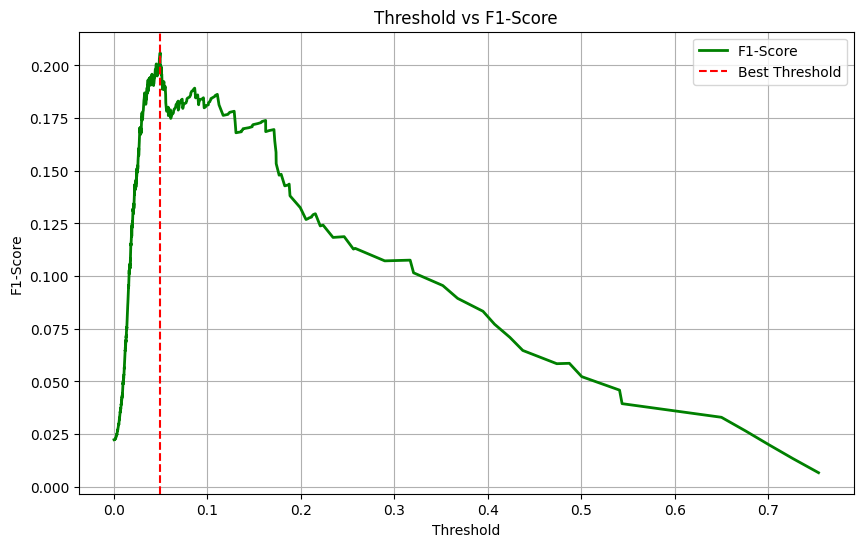

In [9]:
# 1. 1(팔림)이 될 '확률(Probability)'만 따로 추출
proba = final_model.predict_proba(X_test)[:, 1]

# 2. 다양한 임계값(Threshold) 테스트
thresholds = np.arange(0.05, 0.95, 0.05)
best_f1 = 0
best_thresh = 0.5

print('Threshold | Precision | Recall | F1-Score')
print('-' * 45)
for thresh in thresholds:
    # 확률이 thresh 이상일 때만 1로 예측
    custom_preds = (proba >= thresh).astype(int)

    p = precision_score(y_test, custom_preds, zero_division=0)
    r = recall_score(y_test, custom_preds)
    f1 = f1_score(y_test, custom_preds)

    print(f'{thresh:.2f}      | {p:.4f}    | {r:.4f} | {f1:.4f}')

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f'\n최적의 Threshold: {best_thresh:.2f} (최고 F1-score: {best_f1:.4f})')


def find_optimal_threshold(y_true, y_proba):
    # 1. 가능한 모든 임계값과 그에 따른 정밀도, 재현율 계산
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)

    # 2. 각 임계값에서의 F1-score 계산 (분모가 0이 되는 것을 방지하기 위해 1e-10 추가)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    # 3. F1-score가 가장 높은 지점의 인덱스 추출
    best_idx = np.argmax(f1_scores)

    # 4. 최적의 임계값과 그때의 F1-score
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print('🌟 [최적 임계값 탐색 결과] 🌟')
    print(f'👉 Best Threshold : {best_threshold:.4f}')
    print(f'👉 Best F1-Score  : {best_f1:.4f}\n')

    return best_threshold


def plot_threshold_curve(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    plt.figure(figsize=(10, 6))
    # thresholds는 precisions/recalls보다 길이가 1 짧으므로 슬라이싱 필요
    plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green', linewidth=2)
    plt.axvline(
        x=thresholds[np.argmax(f1_scores)],
        color='red',
        linestyle='--',
        label='Best Threshold',
    )

    plt.title('Threshold vs F1-Score')
    plt.xlabel('Threshold')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True)
    plt.show()


# 최적 임계값 구하기 (y_test는 테스트 데이터의 실제 정답)
y_proba = final_model.predict_proba(X_test)[:, 1]
best_threshold = find_optimal_threshold(y_test, y_proba)

# 확률값이 best_threshold 이상이면 1.0, 아니면 0.0으로 변환
y_pred_custom = (y_proba >= best_threshold).astype(float)

# 최종 성능 확인
print('✅ [최적 임계값 적용 후 Classification Report]')
print(classification_report(y_test, y_pred_custom))

# 그래프 그리기
plot_threshold_curve(y_test, y_proba)

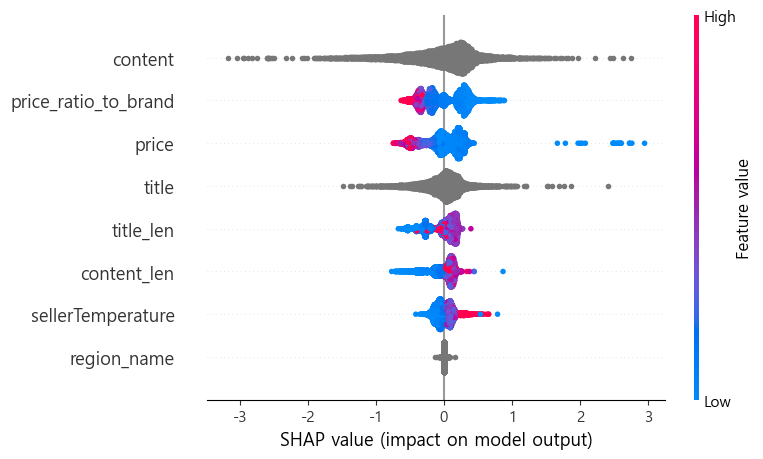

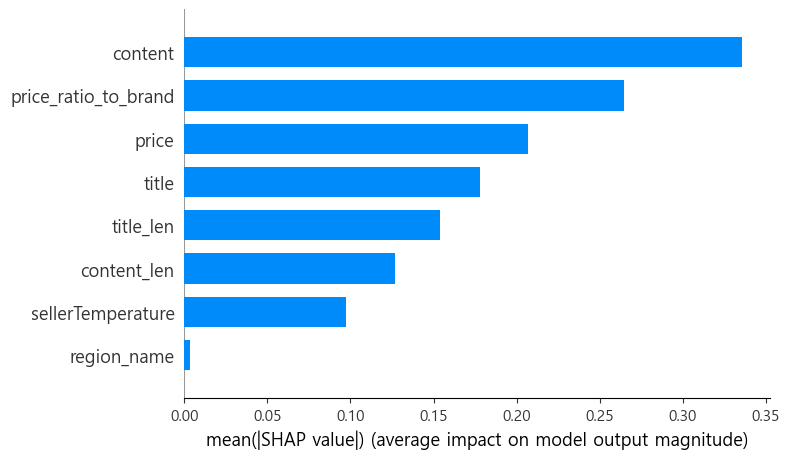

In [10]:
# 맑은 고딕(Malgun Gothic) -> 나눔고딕(NanumGothic)으로 변경
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 텍스트 피처가 있으므로 Pool 형태로 묶어서 에러 방지 (필요 시)
X_test_sample = X_test.sample(n=10000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

sample_pool = Pool(
    X_test_sample, y_test_sample, cat_features=cat_features, text_features=text_features
)

# 1. 트리 모델용 초고속 SHAP Explainer 선언
explainer = shap.TreeExplainer(final_model)

# 2. Test Set 일부에 대한 SHAP 값 계산 (속도가 빨라 더 많이 넣어도 됩니다)
X_test_sample = X_test.sample(n=10000, random_state=42)
# shap_values = explainer(X_test_sample)
shap_values = explainer.shap_values(sample_pool)

# 3. 전체 Feature Importance 시각화 (요약 플롯)
# 피처가 예측값(판매 확률)을 높이는 데 기여했는지 낮추는 데 기여했는지 색상으로 보여줍니다.
shap.summary_plot(shap_values, X_test_sample)

# 4. 단순 막대 그래프로 중요도 순위만 보고 싶을 때
shap.summary_plot(shap_values, X_test_sample, plot_type='bar')

판매 아이템: 슈슈앤크라 에뜨와 여아 점퍼 24개월 일괄판매
본문 내용: 슈슈앤크라 
핑크 메쉬 가디건 (한여름 에어컨용이에요)
화이트 반팔 블라우스
핑크 바람막이

에뜨와 화이트 점퍼

총 4벌 일괄판매합니다. 
컨디션 좋고 오염없이 깨끗합니다. 
슈...
가격: 45000 원
실제 7일 내 판매 여부: ✅ 팔림
🔥 AI 예측 판매 확률: 75.40%



c:\potenup3\pj02_daangn-marke\.venv\Lib\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
c:\potenup3\pj02_daangn-marke\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


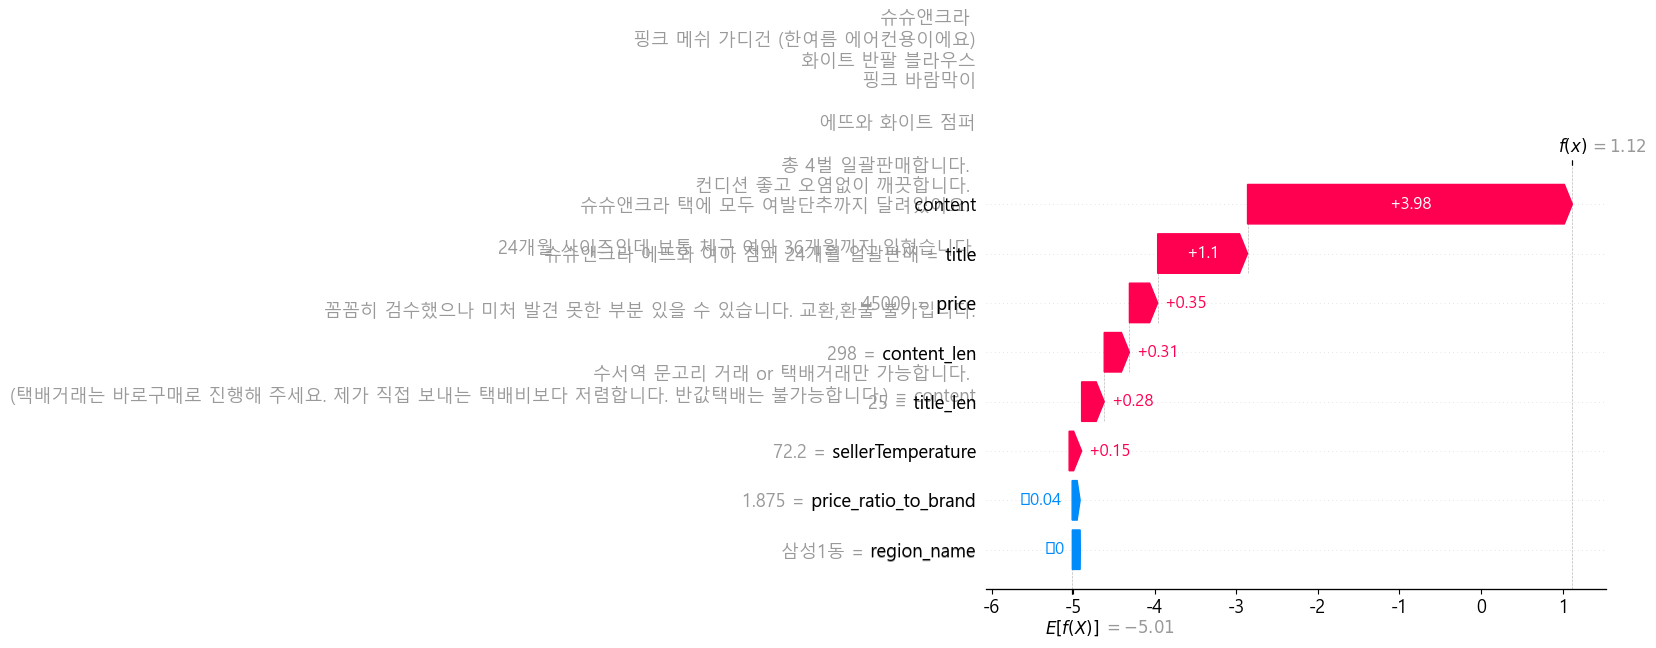

In [11]:
# 맑은 고딕(Malgun Gothic) -> 나눔고딕(NanumGothic)으로 변경
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 1. SHAP TreeExplainer 선언
explainer = shap.TreeExplainer(final_model)

# 2. 분석하고 싶은 데이터 딱 1개 고르기
best_idx = np.argmax(final_model.predict_proba(X_test)[:, 1])
sample_data = X_test.iloc[[best_idx]]
sample_target = y_test.iloc[best_idx]
sample_proba = final_model.predict_proba(sample_data)[0, 1]

# 3. 텍스트 피처 에러 방지를 위한 Pool 객체로 감싸기
sample_pool = catboost.Pool(
    sample_data, cat_features=cat_features, text_features=text_features
)

# 4. SHAP 값 계산
shap_values = explainer(sample_pool)

# ★ 에러 해결의 핵심: SHAP 객체 내부의 'Pool' 데이터를 실제 텍스트/숫자 데이터로 교체 ★
shap_values.data = sample_data.values
shap_values.feature_names = sample_data.columns.tolist()

# 5. 결과 출력 및 Waterfall 차트 시각화
print('==========================================')
print(f'판매 아이템: {sample_data["title"].values[0]}')
print(f'본문 내용: {sample_data["content"].values[0][:100]}...')
print(f'가격: {sample_data["price"].values[0]} 원')
print(f'실제 7일 내 판매 여부: {"✅ 팔림" if sample_target == 1 else "❌ 안 팔림"}')
print(f'🔥 AI 예측 판매 확률: {sample_proba * 100:.2f}%')
print('==========================================\n')

# 폭포수(Waterfall) 차트 그리기
shap.plots.waterfall(shap_values[0], max_display=10)  # 상위 10개 피처만 깔끔하게 보기

In [ ]:
# ---------------------------------------------------------
# [1] 모델 저장 및 필수 매핑(Mapping) 데이터 준비
# ---------------------------------------------------------
# 1. 학습된 CatBoost 모델 저장
# final_model.save_model('../data/models/daangn_sell_predictor.cbm')

NameError: name 'final_model' is not defined

In [12]:
# 1. '가성비' 계산을 위한 평균 가격 정보 딕셔너리화
brand_mean_dict = clean_df.groupby('brandName')['price'].median().to_dict()

# =========================================================
# [전역 세팅] 모델 로드 및 최적 임계값 설정 (서버 가동 시 1회만 실행)
# =========================================================
# 모델 불러오기
loaded_model = CatBoostClassifier()
loaded_model.load_model('../data/models/daangn_sell_predictor_new4.cbm')
# loaded_model.load_model("daangn_sell_predictor_new.cbm")

# 🔥 앞서 찾으신 최적의 F1-Score 임계값을 여기에 입력하세요!
BEST_THRESHOLD = best_threshold


# ---------------------------------------------------------
# [2] 새로운 게시글 예측 함수 만들기
# ---------------------------------------------------------
def make_input_data(
    price, title, content, region_name, brandName, seller_temp=36.5
) -> pd.DataFrame:
    """
    새로운 게시글 정보를 입력받아 판매 확률과 최종 판정 결과를 반환하는 함수
    """
    # 2. 파생 변수(가성비, 길이 등) 계산
    b_mean = brand_mean_dict.get(brandName, price)
    price_ratio_to_brand = price / (b_mean + 1)

    title_len = len(str(title))
    content_len = len(str(content))

    # 3. 모델에 넣을 데이터프레임 구성
    input_data = pd.DataFrame(
        [
            {
                'price': price,
                'title': title,
                'content': content,
                'region_name': region_name if pd.notnull(region_name) else 'unknown',
                'sellerTemperature': seller_temp,
                'title_len': title_len,
                'content_len': content_len,
                'price_ratio_to_brand': price_ratio_to_brand,
            }
        ]
    )
    return input_data


def calibrate_probability(proba, threshold):
    """
    날것의 확률을 유저 친화적인 0~100% 점수로 보정합니다.
    (커트라인을 딱 50%로 맞춥니다)
    """
    if proba < threshold:
        # 0 ~ threshold 구간을 0 ~ 50%로 변환
        calibrated = (proba / threshold) * 50
    else:
        # threshold ~ 1.0 구간을 50% ~ 100%로 변환
        calibrated = 50 + ((proba - threshold) / (1.0 - threshold)) * 50

    # 최대 99.9%를 넘지 않도록 안전장치 (100%라고 하면 너무 단정적이므로)
    return min(calibrated, 99.9)


def predict_sell_probability(input_data) -> tuple[float, int]:

    title = input_data['title'].values[0]
    price = input_data['price'].values[0]
    price_ratio_to_brand = input_data['price_ratio_to_brand'].values[0]

    # 4. 예측 수행 (확률 뽑기)
    proba = loaded_model.predict_proba(input_data)[0, 1]

    # 5. 최적 임계값을 적용한 최종 판정 (0 or 1)
    calibrated_score = calibrate_probability(proba, BEST_THRESHOLD)
    is_sold = (
        1 if calibrated_score >= 50.0 else 0
    )  # 이제 판정 기준이 직관적인 50%가 됩니다!
    # is_sold = 1 if proba >= BEST_THRESHOLD else 0
    verdict = (
        '✅ 빠른 시일 내에 팔릴 확률이 높습니다!'
        if is_sold == 1
        else '⏳ 가격이나 내용 수정이 필요해 보입니다.'
    )

    # 결과 출력
    print('==========================================')
    print(f'🛒 판매 아이템: {title}')
    print(f'💰 희망 가격: {price:,}원 (브랜드 평균 대비 {price_ratio_to_brand:.2f}배)')
    print(
        f'🔥 AI 예측 판매 확률: {proba * 100:.2f}% (기준 커트라인: {BEST_THRESHOLD * 100:.2f}%)'
    )
    print(f'💡 보정된 판매 확률: {min(5 * calibrated_score, 99.9):.2f}%') # heuristic 값 5를 곱해준다.
    # print(f'💡 보정된 판매 확률: {min(6*proba / BEST_THRESHOLD * 100, 99.9):.2f}%')
    print(f'🎯 최종 판정: {verdict}')
    print('==========================================\n')

    return proba, is_sold


# ---------------------------------------------------------
# [3] 가상 데이터로 즉석 테스트 해보기
# ---------------------------------------------------------
# 가상 데이터 1: 매력적인 조건의 글

input_data1 = make_input_data(
    title='나이키 스우시 크롭 맨투맨 블랙',
    content='나이키 스우시 크롭 맨투맨 블랙 색상입니다\n- 모델명: DQ5896\n- 사이즈 S\n- 오버사이즈\n- 기모 안감이라 따뜻해요\n\n편하게 입기 좋아요~',
    price=13000,
    brandName='nike',
    region_name='역삼동',
    seller_temp=37.7,
)

proba1, sold1 = predict_sell_probability(input_data1)

# 가상 데이터 2: 안 팔릴 것 같은 글
input_data2 = make_input_data(
    title='나이키 패딩',
    content='입을만 합니다 네고 불가',
    price=150000,
    brandName='nike',
    region_name='역삼동',
    seller_temp=36.5,
)

proba2, sold2 = predict_sell_probability(input_data2)

🛒 판매 아이템: 나이키 스우시 크롭 맨투맨 블랙
💰 희망 가격: 13,000원 (브랜드 평균 대비 0.43배)
🔥 AI 예측 판매 확률: 1.27% (기준 커트라인: 4.94%)
💡 보정된 판매 확률: 64.44%
🎯 최종 판정: ⏳ 가격이나 내용 수정이 필요해 보입니다.

🛒 판매 아이템: 나이키 패딩
💰 희망 가격: 150,000원 (브랜드 평균 대비 5.00배)
🔥 AI 예측 판매 확률: 0.09% (기준 커트라인: 4.94%)
💡 보정된 판매 확률: 4.63%
🎯 최종 판정: ⏳ 가격이나 내용 수정이 필요해 보입니다.



In [13]:
# 1. 전체 Test 데이터에 예측 확률과 실제 정답 붙이기
analysis_df = X_test.copy()
analysis_df['actual_target'] = y_test
analysis_df['pred_proba'] = final_model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# [유형 1] False Positive (FP): 모델은 무조건 팔린다고(85% 이상) 했는데, 안 팔린 상품
# ---------------------------------------------------------
false_positives = analysis_df[
    (analysis_df['actual_target'] == 0) & (analysis_df['pred_proba'] >= 0.85)
].sort_values(by='pred_proba', ascending=False)

print(
    f'🚨 [False Positives] 모델은 팔린다고 확신했지만 안 팔린 게시글: {len(false_positives)}개'
)

# 상위 5개 뽑아보기
for idx, row in false_positives.head(5).iterrows():
    # ★ 수정된 부분: X_test에 없는 브랜드명은 원본 train_df에서 인덱스(idx)로 가져옵니다.
    original_brand = clean_df.loc[idx, 'brandName']

    print(
        f'확률: {row["pred_proba"]:.2f} | 가격: {row["price"]:,.0f}원 | 브랜드: {original_brand}'
    )
    print(f'제목: {row["title"]}')
    print(f'본문: {row["content"][:100]}...')  # 본문은 100자까지만
    print('-' * 50)


print('\n\n')


# ---------------------------------------------------------
# [유형 2] False Negative (FN): 모델은 절대 안 팔린다고(10% 이하) 했는데, 팔린 상품
# ---------------------------------------------------------
false_negatives = analysis_df[
    (analysis_df['actual_target'] == 1) & (analysis_df['pred_proba'] <= 0.10)
].sort_values(by='pred_proba', ascending=True)

print(
    f'🚨 [False Negatives] 모델은 안 팔린다고 확신했지만 실제론 팔린 게시글: {len(false_negatives)}개'
)

# 하위 5개 뽑아보기
for idx, row in false_negatives.head(5).iterrows():
    # ★ 수정된 부분
    original_brand = clean_df.loc[idx, 'brandName']

    print(
        f'확률: {row["pred_proba"]:.2f} | 가격: {row["price"]:,.0f}원 | 브랜드: {original_brand}'
    )
    print(f'제목: {row["title"]}')
    print(f'본문: {row["content"][:100]}...')
    print('-' * 50)

🚨 [False Positives] 모델은 팔린다고 확신했지만 안 팔린 게시글: 0개



🚨 [False Negatives] 모델은 안 팔린다고 확신했지만 실제론 팔린 게시글: 264개
확률: 0.00 | 가격: 75,000원 | 브랜드: hazzys
제목: 헤지스 롱 퀼팅 점퍼
본문: 가슴단면48 총장92
헤지스 롱 퀼팅 점퍼에요
폴리 소재이고 얇은편이에요
봄가을에 입기 좋아요 깔끔하고 이뻐요


워킹맘이라 택배 거래해요
직거래는 남편이 주말에 가끔나가요...
--------------------------------------------------
확률: 0.00 | 가격: 350,000원 | 브랜드: unknown
제목: 아보아보 2부 드레스 (WOOL SILK SQUARE NECK LINE FLARE DRESS) / 사이즈2
본문: 아보아보 2부 드레스 사이즈2입니다.
연예인들이 워낙 많이 착용하는 제품으로 아이유,소이현,박민영,김태리 등이 착용한 모습을 보고 결혼식 2부로 구입했습니다.
당시 정가 989,0...
--------------------------------------------------
확률: 0.00 | 가격: 450,000원 | 브랜드: unknown
제목: (XL) 유니온블루 블랙에디션 램스킨 레더 자켓
본문: 유니온블루 블랙에디션 램스킨 레더 자켓 XL사이즈입니다. 택만 제거 후 집에서 시착만 해본 제품으로 새제품과 같은 컨디션입니다.
옷장 정리중이라 가장 저렴한 가격으로 판매합니다....
--------------------------------------------------
확률: 0.00 | 가격: 4,000원 | 브랜드: unknown
제목: 아이러브제 5부 반바지
본문: 3XL 신축성 있고 편한 소재입니다.
청바지는 150 사이즈인데 비브랜ㄷ
여서 함께 드리겠습니다

반값택배, 도곡1동 직거래 가능해요...
--------------------------------------------------
확률: 0.00 |

## 2. Buyer-side Model

In [19]:
buy_features = [
    'price',
    'title',
    'content',
    'region_name',
    'favoriteCount',
    'chatCount',
    'viewCount',
    'sellerTemperature',
    'is_boosted',
    'title_len',
    'content_len',
    'favorite_per_view',
    'chat_per_view',
    'price_ratio_to_brand',
]

In [20]:
X = clean_df[buy_features]
y = clean_df['target_n_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_features = ['region_name']
text_features = ['title', 'content']

# ★ Optuna 속도 최적화를 위해 Pool 객체 미리 생성 ★
train_pool = Pool(
    X_train, y_train, cat_features=cat_features, text_features=text_features
)
valid_pool = Pool(
    X_test, y_test, cat_features=cat_features, text_features=text_features
)

In [21]:
# ==========================================
# 2. Optuna Objective 함수 정의
# ==========================================


def objective(trial):
    # 탐색할 하이퍼파라미터 공간 정의
    param = {
        'iterations': trial.suggest_int('iterations', 500, 1500),  # 학습 횟수
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int(
            'depth', 4, 12
        ),  # 텍스트 모델은 메모리를 많이 쓰므로 최대 8 권장
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 1e-3, 10.0, log=True
        ),  # 정규화
        'random_strength': trial.suggest_float(
            'random_strength', 1e-3, 10.0, log=True
        ),  # 과적합 방지
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'bootstrap_type': 'Bayesian',  # 🌟 수정됨: GPU 환경에서 bagging_temperature 쓸 때 필수
        # 고정 파라미터
        'eval_metric': 'Logloss',
        'random_seed': 42,
        #'auto_class_weights': 'SqrtBalanced',
        'task_type': 'GPU',
        'verbose': 0,  # 튜닝 중에는 로그 출력 끄기
    }

    model = CatBoostClassifier(**param)

    # 모델 학습 (Early Stopping 적용)
    model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

    # 검증셋에서 가장 높았던 PR-AUC 점수를 반환
    proba = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, proba)

    return pr_auc


# ==========================================
# 3. Optuna Study 실행 (탐색 시작)
# ==========================================
print('🚀 Optuna 하이퍼파라미터 탐색을 시작합니다...')
study = optuna.create_study(direction='maximize')  # AUC는 높을수록 좋으므로 maximize
study.optimize(
    objective, n_trials=100
)  # 우선 30번만 시도 (시간에 따라 50~100번으로 늘려보세요)

print('\n🏆 [Best Trial]')
print(f'최고 PR-AUC 점수: {study.best_value:.4f}')
print('최적의 파라미터:')
for key, value in study.best_params.items():
    print(f'  {key}: {value}')

# ==========================================
# 4. 찾은 최적 파라미터로 최종 모델 학습 및 평가
# ==========================================
print('\n🔥 찾은 최적의 파라미터로 최종 모델을 학습합니다...')
best_params = study.best_params

# 고정 파라미터 다시 추가
best_params.update(
    {
        'eval_metric': 'Logloss',
        'random_seed': 42,
        #'auto_class_weights': 'SqrtBalanced',
        'task_type': 'GPU',
        'verbose': 50,  # 최종 학습이므로 로그 출력
    }
)

final_model = CatBoostClassifier(**best_params)
final_model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

# 최종 평가
preds = final_model.predict(X_test)
proba = final_model.predict_proba(X_test)[:, 1]

print('\n✅ [최종 모델 평가 지표]')
print(classification_report(y_test, preds))
print(f'PR-AUC: {average_precision_score(y_test, proba):.4f}')

# ==========================================
# 5. Permutation Importance 계산 (최종 1회)
# ==========================================
print('\n📊 Permutation Importance 계산 중... (시간이 조금 소요됩니다)')
X_test_sample = X_test.sample(n=10000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

# 텍스트 피처가 있으므로 Pool 형태로 묶어서 에러 방지 (필요 시)
sample_pool = Pool(
    X_test_sample, y_test_sample, cat_features=cat_features, text_features=text_features
)

result = permutation_importance(
    final_model,
    X_test_sample,  # Pool이 아닌 DataFrame 자체를 넣어야 사이킷런과 호환됨
    y_test_sample,
    n_repeats=6,
    random_state=42,
    scoring='average_precision',
    n_jobs=-1,
)

perm_imp_df = pd.DataFrame(
    {
        'Feature': X_test_sample.columns,
        'Importance': result.importances_mean,
        'Std': result.importances_std,
    }
).sort_values(by='Importance', ascending=False)

print('\n[Permutation Importance 결과]')
print(perm_imp_df)

# 최종 모델 저장 (선택)
final_model.save_model('daangn_buy_predictor_new.cbm')

[I 2026-03-11 10:50:39,180] A new study created in memory with name: no-name-5260c695-7b93-4e3e-8c16-f783c45dcba0


🚀 Optuna 하이퍼파라미터 탐색을 시작합니다...


[I 2026-03-11 10:50:45,559] Trial 0 finished with value: 0.3616371448696336 and parameters: {'iterations': 817, 'learning_rate': 0.10702544400584149, 'depth': 9, 'l2_leaf_reg': 0.008325295211781497, 'random_strength': 0.07503239763158422, 'bagging_temperature': 0.7169968556752212}. Best is trial 0 with value: 0.3616371448696336.
[I 2026-03-11 10:50:50,994] Trial 1 finished with value: 0.37645652835649906 and parameters: {'iterations': 1231, 'learning_rate': 0.10017490435586002, 'depth': 6, 'l2_leaf_reg': 0.021552028848065997, 'random_strength': 0.0017000352122114842, 'bagging_temperature': 0.7464499357020933}. Best is trial 1 with value: 0.37645652835649906.
[I 2026-03-11 10:51:04,385] Trial 2 finished with value: 0.37099734553913394 and parameters: {'iterations': 848, 'learning_rate': 0.15072771215259104, 'depth': 11, 'l2_leaf_reg': 0.0199453683110686, 'random_strength': 0.001967861595216853, 'bagging_temperature': 0.8041124566310709}. Best is trial 1 with value: 0.37645652835649906.



🏆 [Best Trial]
최고 PR-AUC 점수: 0.4305
최적의 파라미터:
  iterations: 1302
  learning_rate: 0.014428945597135763
  depth: 10
  l2_leaf_reg: 0.2768732787475422
  random_strength: 8.041977377043626
  bagging_temperature: 0.37691179851380235

🔥 찾은 최적의 파라미터로 최종 모델을 학습합니다...
0:	learn: 0.6618280	test: 0.6617394	best: 0.6617394 (0)	total: 53.9ms	remaining: 1m 10s
50:	learn: 0.0748134	test: 0.0746337	best: 0.0746337 (50)	total: 3.02s	remaining: 1m 14s
100:	learn: 0.0390648	test: 0.0398400	best: 0.0398400 (100)	total: 6.11s	remaining: 1m 12s
150:	learn: 0.0342618	test: 0.0359522	best: 0.0359522 (150)	total: 9.38s	remaining: 1m 11s
200:	learn: 0.0322666	test: 0.0348442	best: 0.0348442 (200)	total: 12.5s	remaining: 1m 8s
250:	learn: 0.0310692	test: 0.0343179	best: 0.0343179 (250)	total: 15.4s	remaining: 1m 4s
300:	learn: 0.0300905	test: 0.0340096	best: 0.0340094 (299)	total: 18.6s	remaining: 1m 1s
350:	learn: 0.0292029	test: 0.0337540	best: 0.0337540 (350)	total: 21.9s	remaining: 59.3s
400:	learn: 0.02859

Threshold | Precision | Recall | F1-Score
---------------------------------------------
0.05      | 0.2229    | 0.7584 | 0.3445
0.10      | 0.2833    | 0.7215 | 0.4068
0.15      | 0.3339    | 0.6208 | 0.4343
0.20      | 0.4036    | 0.5336 | 0.4595
0.25      | 0.4508    | 0.4463 | 0.4486
0.30      | 0.5324    | 0.3859 | 0.4475
0.35      | 0.5860    | 0.3087 | 0.4044
0.40      | 0.6316    | 0.2416 | 0.3495
0.45      | 0.6707    | 0.1846 | 0.2895
0.50      | 0.7241    | 0.1409 | 0.2360
0.55      | 0.7000    | 0.0940 | 0.1657
0.60      | 0.7714    | 0.0906 | 0.1622
0.65      | 0.8400    | 0.0705 | 0.1300
0.70      | 0.8947    | 0.0570 | 0.1073
0.75      | 0.9231    | 0.0403 | 0.0772
0.80      | 0.8889    | 0.0268 | 0.0521
0.85      | 1.0000    | 0.0235 | 0.0459
0.90      | 0.0000    | 0.0000 | 0.0000

최적의 Threshold: 0.20 (최고 F1-score: 0.4595)
🌟 [최적 임계값 탐색 결과] 🌟
👉 Best Threshold : 0.1851
👉 Best F1-Score  : 0.4651

✅ [최적 임계값 적용 후 Classification Report]
              precision    recall  f1-s

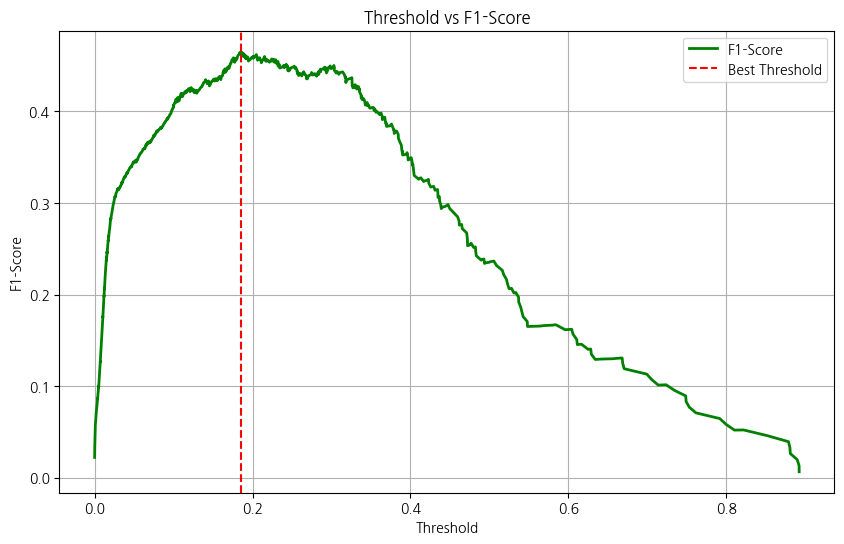

In [22]:
# 1. 1(팔림)이 될 '확률(Probability)'만 따로 추출
proba = final_model.predict_proba(X_test)[:, 1]

# 2. 다양한 임계값(Threshold) 테스트
thresholds = np.arange(0.05, 0.95, 0.05)
best_f1 = 0
best_thresh = 0.5

print('Threshold | Precision | Recall | F1-Score')
print('-' * 45)
for thresh in thresholds:
    # 확률이 thresh 이상일 때만 1로 예측
    custom_preds = (proba >= thresh).astype(int)

    p = precision_score(y_test, custom_preds, zero_division=0)
    r = recall_score(y_test, custom_preds)
    f1 = f1_score(y_test, custom_preds)

    print(f'{thresh:.2f}      | {p:.4f}    | {r:.4f} | {f1:.4f}')

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f'\n최적의 Threshold: {best_thresh:.2f} (최고 F1-score: {best_f1:.4f})')


def find_optimal_threshold(y_true, y_proba):
    # 1. 가능한 모든 임계값과 그에 따른 정밀도, 재현율 계산
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)

    # 2. 각 임계값에서의 F1-score 계산 (분모가 0이 되는 것을 방지하기 위해 1e-10 추가)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    # 3. F1-score가 가장 높은 지점의 인덱스 추출
    best_idx = np.argmax(f1_scores)

    # 4. 최적의 임계값과 그때의 F1-score
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print('🌟 [최적 임계값 탐색 결과] 🌟')
    print(f'👉 Best Threshold : {best_threshold:.4f}')
    print(f'👉 Best F1-Score  : {best_f1:.4f}\n')

    return best_threshold


def plot_threshold_curve(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    plt.figure(figsize=(10, 6))
    # thresholds는 precisions/recalls보다 길이가 1 짧으므로 슬라이싱 필요
    plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green', linewidth=2)
    plt.axvline(
        x=thresholds[np.argmax(f1_scores)],
        color='red',
        linestyle='--',
        label='Best Threshold',
    )

    plt.title('Threshold vs F1-Score')
    plt.xlabel('Threshold')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True)
    plt.show()


# 최적 임계값 구하기 (y_test는 테스트 데이터의 실제 정답)
y_proba = final_model.predict_proba(X_test)[:, 1]
best_threshold = find_optimal_threshold(y_test, y_proba)

# 확률값이 best_threshold 이상이면 1.0, 아니면 0.0으로 변환
y_pred_custom = (y_proba >= best_threshold).astype(float)

# 최종 성능 확인
print('✅ [최적 임계값 적용 후 Classification Report]')
print(classification_report(y_test, y_pred_custom))

# 그래프 그리기
plot_threshold_curve(y_test, y_proba)

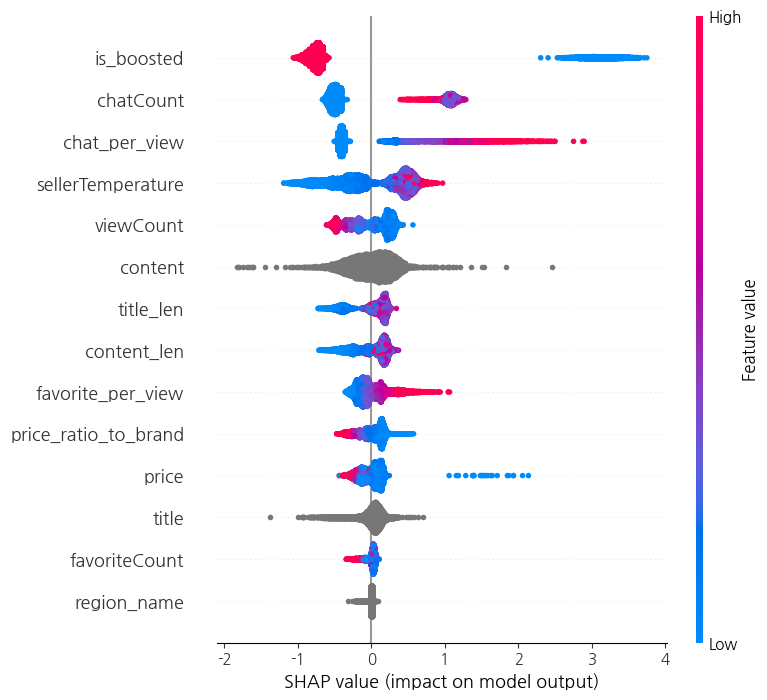

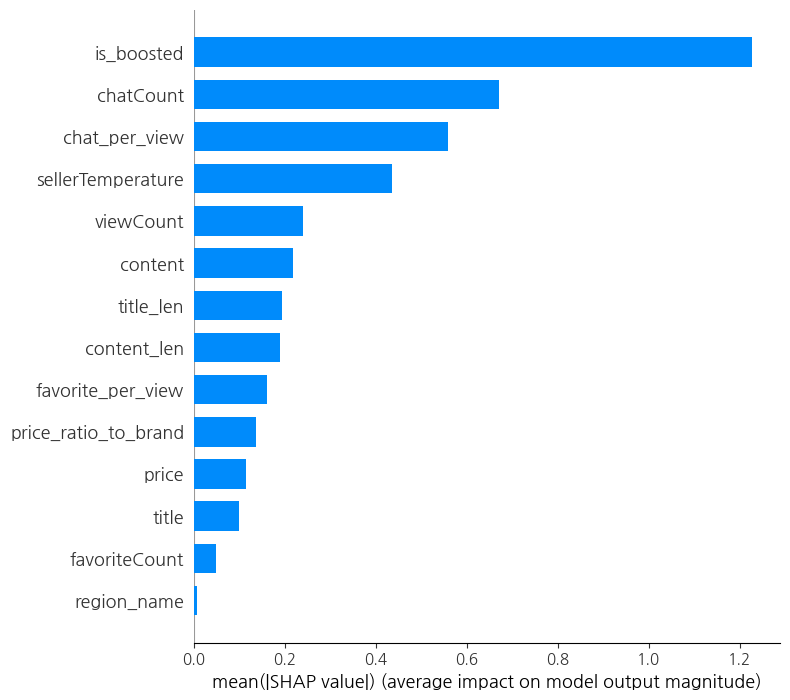

In [ ]:
# 맑은 고딕(Malgun Gothic) -> 나눔고딕(NanumGothic)으로 변경
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 텍스트 피처가 있으므로 Pool 형태로 묶어서 에러 방지 (필요 시)
X_test_sample = X_test.sample(n=10000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

sample_pool = Pool(
    X_test_sample, y_test_sample, cat_features=cat_features, text_features=text_features
)

# 1. 트리 모델용 초고속 SHAP Explainer 선언
explainer = shap.TreeExplainer(final_model)

# 2. Test Set 일부에 대한 SHAP 값 계산 (속도가 빨라 더 많이 넣어도 됩니다)
X_test_sample = X_test.sample(n=10000, random_state=42)
# shap_values = explainer(X_test_sample)
shap_values = explainer.shap_values(sample_pool)

# 3. 전체 Feature Importance 시각화 (요약 플롯)
# 피처가 예측값(판매 확률)을 높이는 데 기여했는지 낮추는 데 기여했는지 색상으로 보여줍니다.
shap.summary_plot(shap_values, X_test_sample)

# 4. 단순 막대 그래프로 중요도 순위만 보고 싶을 때
shap.summary_plot(shap_values, X_test_sample, plot_type='bar')

판매 아이템: 폴로 랄프로렌 키즈 옥스포드 셔츠 6Y
본문 내용: 폴로 랄프로렌 남아 셔츠입니다
아이 한명 착용으로 세탁감 있으나 전체적으로 아주 깨끗합니다.
📌 사이즈 6Y

후기 보면 아시겠지만 깨끗한 상품만 올리니  따로 안물어보셔도 됩니다...
가격: 12000 원
실제 7일 내 판매 여부: ✅ 팔림
🔥 AI 예측 판매 확률: 89.23%



/home/wanted-1/WantedPotenUp/personal/seunghun/pj02_Daangn-marke/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


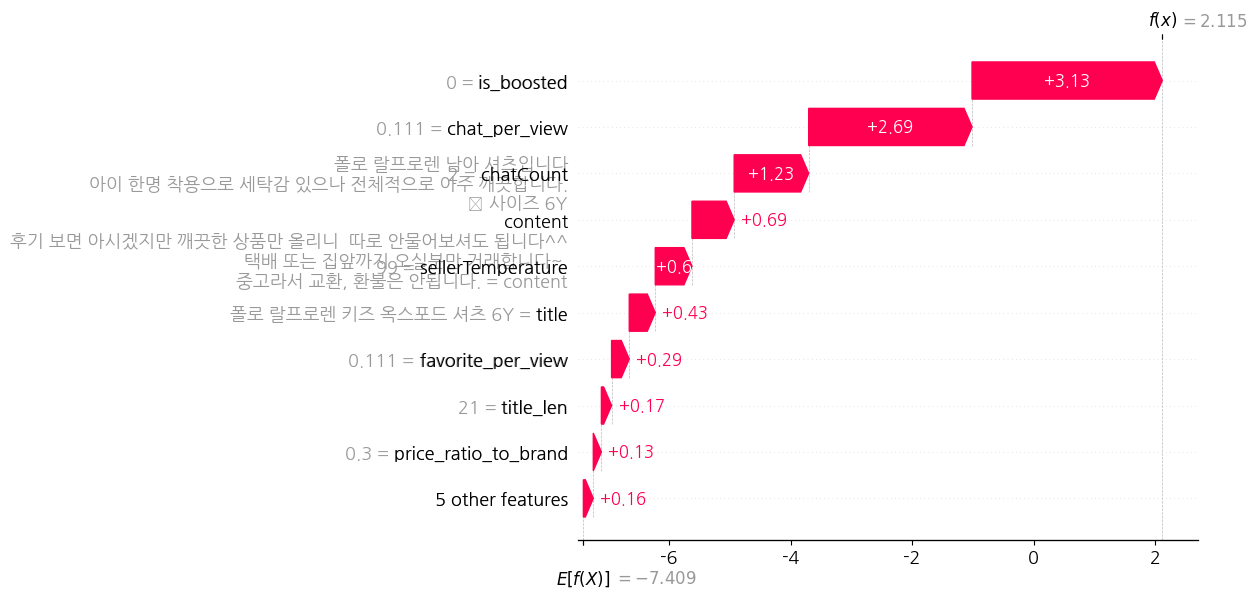

In [ ]:
# 맑은 고딕(Malgun Gothic) -> 나눔고딕(NanumGothic)으로 변경
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 1. SHAP TreeExplainer 선언
explainer = shap.TreeExplainer(final_model)

# 2. 분석하고 싶은 데이터 딱 1개 고르기
best_idx = np.argmax(final_model.predict_proba(X_test)[:, 1])
sample_data = X_test.iloc[[best_idx]]
sample_target = y_test.iloc[best_idx]
sample_proba = final_model.predict_proba(sample_data)[0, 1]

# 3. 텍스트 피처 에러 방지를 위한 Pool 객체로 감싸기
sample_pool = catboost.Pool(
    sample_data, cat_features=cat_features, text_features=text_features
)

# 4. SHAP 값 계산
shap_values = explainer(sample_pool)

# ★ 에러 해결의 핵심: SHAP 객체 내부의 'Pool' 데이터를 실제 텍스트/숫자 데이터로 교체 ★
shap_values.data = sample_data.values
shap_values.feature_names = sample_data.columns.tolist()

# 5. 결과 출력 및 Waterfall 차트 시각화
print('==========================================')
print(f'판매 아이템: {sample_data["title"].values[0]}')
print(f'본문 내용: {sample_data["content"].values[0][:100]}...')
print(f'가격: {sample_data["price"].values[0]} 원')
print(f'실제 7일 내 판매 여부: {"✅ 팔림" if sample_target == 1 else "❌ 안 팔림"}')
print(f'🔥 AI 예측 판매 확률: {sample_proba * 100:.2f}%')
print('==========================================\n')

# 폭포수(Waterfall) 차트 그리기
shap.plots.waterfall(shap_values[0], max_display=10)  # 상위 10개 피처만 깔끔하게 보기

In [27]:
# 1. '가성비' 계산을 위한 평균 가격 정보 딕셔너리화
brand_mean_dict = clean_df.groupby('brandName')['price'].median().to_dict()

# =========================================================
# [전역 세팅] 모델 로드 및 최적 임계값 설정 (서버 가동 시 1회만 실행)
# =========================================================
# 모델 불러오기
loaded_model = CatBoostClassifier()
# loaded_model.load_model('../data/models/daangn_sell_predictor_new2.cbm')
loaded_model.load_model('daangn_buy_predictor_new.cbm')

# 🔥 앞서 찾으신 최적의 F1-Score 임계값을 여기에 입력하세요!
BEST_THRESHOLD = best_threshold


# ---------------------------------------------------------
# [2] 새로운 게시글 예측 함수 만들기
# ---------------------------------------------------------
def make_input_data(
    price,
    title,
    content,
    region_name,
    favoriteCount,
    chatCount,
    viewCount,
    brandName,
    is_boosted,
    seller_temp=36.5,
) -> pd.DataFrame:
    """
    새로운 게시글 정보를 입력받아 판매 확률과 최종 판정 결과를 반환하는 함수
    """
    # 2. 파생 변수(가성비, 길이 등) 계산
    b_mean = brand_mean_dict.get(brandName, price)
    price_ratio_to_brand = price / (b_mean + 1)

    title_len = len(str(title))
    content_len = len(str(content))

    # 3. 모델에 넣을 데이터프레임 구성
    input_data = pd.DataFrame(
        [
            {
                'price': price,
                'title': title,
                'content': content,
                'region_name': region_name,
                'favoriteCount': favoriteCount,
                'chatCount': chatCount,
                'viewCount': viewCount,
                'sellerTemperature': seller_temp,
                'is_boosted': is_boosted,
                'title_len': title_len,
                'content_len': content_len,
                'favorite_per_view': favoriteCount / (viewCount + 1),
                'chat_per_view': chatCount / (viewCount + 1),
                'price_ratio_to_brand': price_ratio_to_brand,
            }
        ]
    )
    return input_data


def calibrate_probability(proba, threshold):
    """
    날것의 확률을 유저 친화적인 0~100% 점수로 보정합니다.
    (커트라인을 딱 50%로 맞춥니다)
    """
    if proba < threshold:
        # 0 ~ threshold 구간을 0 ~ 50%로 변환
        calibrated = (proba / threshold) * 50
    else:
        # threshold ~ 1.0 구간을 50% ~ 100%로 변환
        calibrated = 50 + ((proba - threshold) / (1.0 - threshold)) * 50

    # 최대 99.9%를 넘지 않도록 안전장치 (100%라고 하면 너무 단정적이므로)
    return min(calibrated, 99.9)


def predict_sell_probability(input_data) -> tuple[float, int]:

    title = input_data['title'].values[0]
    price = input_data['price'].values[0]
    price_ratio_to_brand = input_data['price_ratio_to_brand'].values[0]

    # 4. 예측 수행 (확률 뽑기)
    proba = loaded_model.predict_proba(input_data)[0, 1]

    # 5. 최적 임계값을 적용한 최종 판정 (0 or 1)
    calibrated_score = calibrate_probability(proba, BEST_THRESHOLD)
    is_sold = (
        1 if calibrated_score >= 50.0 else 0
    )  # 이제 판정 기준이 직관적인 50%가 됩니다!
    # is_sold = 1 if proba >= BEST_THRESHOLD else 0
    verdict = (
        '✅ 빠른 시일 내에 팔릴 확률이 높습니다!'
        if is_sold == 1
        else '⏳ 가격이나 내용 수정이 필요해 보입니다.'
    )

    # 결과 출력
    print('==========================================')
    print(f'🛒 판매 아이템: {title}')
    print(f'💰 희망 가격: {price:,}원 (브랜드 평균 대비 {price_ratio_to_brand:.2f}배)')
    print(
        f'🔥 AI 예측 판매 확률: {proba * 100:.2f}% (기준 커트라인: {BEST_THRESHOLD * 100:.2f}%)'
    )
    print(f'💡 보정된 판매 확률: {min(2 * calibrated_score, 99.9):.2f}%')
    # print(f'💡 보정된 판매 확률: {min(6*proba / BEST_THRESHOLD * 100, 99.9):.2f}%')
    print(f'🎯 최종 판정: {verdict}')
    print('==========================================\n')

    return proba, is_sold


# ---------------------------------------------------------
# [3] 가상 데이터로 즉석 테스트 해보기
# ---------------------------------------------------------
# 가상 데이터 1: 매력적인 조건의 글

input_data1 = make_input_data(
    title='나이키 숏패딩 블랙 M 급처합니다',
    content='선물 받았는데 사이즈가 안 맞아서 팝니다. 급처합니다. \n택 안 뗀 새상품이에요. \n쿨거래 시 택포해드림.',
    price=25000,
    brandName='nike',
    region_name='역삼동',
    favoriteCount=10,
    chatCount=5,
    viewCount=100,
    is_boosted=0,
    seller_temp=42.2,
)

proba1, sold1 = predict_sell_probability(input_data1)

# 가상 데이터 2: 안 팔릴 것 같은 글
input_data2 = make_input_data(
    title='나이키 패딩',
    content='입을만 합니다 네고 불가',
    price=150000,
    brandName='nike',
    region_name='역삼동',
    favoriteCount=2,
    chatCount=1,
    viewCount=100,
    is_boosted=0,
    seller_temp=36.5,
)

proba2, sold2 = predict_sell_probability(input_data2)

🛒 판매 아이템: 나이키 숏패딩 블랙 M 급처합니다
💰 희망 가격: 25,000원 (브랜드 평균 대비 0.83배)
🔥 AI 예측 판매 확률: 29.63% (기준 커트라인: 18.51%)
💡 보정된 판매 확률: 99.90%
🎯 최종 판정: ✅ 빠른 시일 내에 팔릴 확률이 높습니다!

🛒 판매 아이템: 나이키 패딩
💰 희망 가격: 150,000원 (브랜드 평균 대비 5.00배)
🔥 AI 예측 판매 확률: 3.30% (기준 커트라인: 18.51%)
💡 보정된 판매 확률: 17.82%
🎯 최종 판정: ⏳ 가격이나 내용 수정이 필요해 보입니다.



In [28]:
# 1. 전체 Test 데이터에 예측 확률과 실제 정답 붙이기
analysis_df = X_test.copy()
analysis_df['actual_target'] = y_test
analysis_df['pred_proba'] = final_model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# [유형 1] False Positive (FP): 모델은 무조건 팔린다고(85% 이상) 했는데, 안 팔린 상품
# ---------------------------------------------------------
false_positives = analysis_df[
    (analysis_df['actual_target'] == 0) & (analysis_df['pred_proba'] >= 0.85)
].sort_values(by='pred_proba', ascending=False)

print(
    f'🚨 [False Positives] 모델은 팔린다고 확신했지만 안 팔린 게시글: {len(false_positives)}개'
)

# 상위 5개 뽑아보기
for idx, row in false_positives.head(5).iterrows():
    # ★ 수정된 부분: X_test에 없는 브랜드명은 원본 train_df에서 인덱스(idx)로 가져옵니다.
    original_brand = clean_df.loc[idx, 'brandName']

    print(
        f'확률: {row["pred_proba"]:.2f} | 가격: {row["price"]:,.0f}원 | 브랜드: {original_brand}'
    )
    print(f'제목: {row["title"]}')
    print(f'본문: {row["content"][:100]}...')  # 본문은 100자까지만
    print('-' * 50)


print('\n\n')


# ---------------------------------------------------------
# [유형 2] False Negative (FN): 모델은 절대 안 팔린다고(10% 이하) 했는데, 팔린 상품
# ---------------------------------------------------------
false_negatives = analysis_df[
    (analysis_df['actual_target'] == 1) & (analysis_df['pred_proba'] <= 0.10)
].sort_values(by='pred_proba', ascending=True)

print(
    f'🚨 [False Negatives] 모델은 안 팔린다고 확신했지만 실제론 팔린 게시글: {len(false_negatives)}개'
)

# 하위 5개 뽑아보기
for idx, row in false_negatives.head(5).iterrows():
    # ★ 수정된 부분
    original_brand = clean_df.loc[idx, 'brandName']

    print(
        f'확률: {row["pred_proba"]:.2f} | 가격: {row["price"]:,.0f}원 | 브랜드: {original_brand}'
    )
    print(f'제목: {row["title"]}')
    print(f'본문: {row["content"][:100]}...')
    print('-' * 50)

🚨 [False Positives] 모델은 팔린다고 확신했지만 안 팔린 게시글: 0개



🚨 [False Negatives] 모델은 안 팔린다고 확신했지만 실제론 팔린 게시글: 83개
확률: 0.00 | 가격: 115,000원 | 브랜드: polo ralph lauren
제목: 폴로 랄프로렌 브라운 무스탕 자켓
본문: 폴로 랄프로렌 브라운 무스탕 자켓 
사이즈 95-105 
- 총장 62cm, 가슴 60cm, 어깨 55cm입니다

ㅜㅜ.. 옷이 예뻐보여서 평소 110입는데 주문해서 입어보니 뒷쪽...
--------------------------------------------------
확률: 0.00 | 가격: 38,000원 | 브랜드: titleist
제목: 타이틀리스트 간절기 긴팔 (95)
본문: *구매전 안내 사항 ^^
제가 책임져드리는 부분은 아래와 같습니다
-제가 못 입는 상태의 옷은 절대 판매 못합니다
-헉 놓친 부분은 인정, 환불 및 택배비 보상해드려요


타이틀 ...
--------------------------------------------------
확률: 0.00 | 가격: 48,000원 | 브랜드: the north face
제목: 노스페이스 여성 플리스 XS (85) 아이보리
본문: 노스페이스 여성 플리스 자켓입니다
- 사이즈: XS (85)
- 색상: 아이보리
거의 새상품입니다~...
--------------------------------------------------
확률: 0.00 | 가격: 12,000원 | 브랜드: uniqlo
제목: 정품 유니클로 틴트 안경 선글라스
본문: 두달 전 매장구매.
새거지만 테이블에 올려둬서 한번 닦고 쓰세요.
현금 직거래, 택배X...
--------------------------------------------------
확률: 0.00 | 가격: 12,000원 | 브랜드: topten
제목: 아이러브제이 반바지 / 탑텐반바지 (총3벌)
본문: -블루, 베이지 : 아이러브제이 